# 2.3.2 — Countries and institutions: the benchmarks

`results/bench_affiliations.csv` — 165 measurements on the Cloud Veneto cluster (5 × `cloudveneto.medium`: 1 scheduler + 4 workers with 2 cores and 4 GB each), 11 September 2026.

One row = one measurement. The configuration of each measurement is read from the **state columns** (`partizioni`, `worker`, `thread`), never from the `curva` label; `thread` is the cluster total, so threads per worker is `thread / worker`. The `curva=pandas` rows are the same work on a single core of the same VM.

The CSV keeps the Italian column names written by `bench_affiliations.py`:

| column | meaning |
|---|---|
| `curva` | which curve the measurement belongs to: `partizioni` (partition sweep), `worker`, `pandas` (single-core baseline) |
| `valore` | the value of that curve's independent variable |
| `secondi` | wall-clock seconds of the timed computation |
| `errore` | the exception, when the measurement did not complete (none here: 165 measurements, zero errors) |
| `partizioni`, `file`, `worker`, `thread` | state of the run |

Error bars are the standard deviation across the campaign passes. The table below is the shape of the campaign: how many measurements per configuration and per `k`.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12, "axes.titleweight": "bold", "legend.frameon": False,
})
BLUE, ORANGE, GREEN, GREY = "#2b6cb0", "#dd6b20", "#2f855a", "#8a8a8a"

def label(workers, threads):
    return f"{workers} worker{'s' * (workers > 1)} × {threads} thread{'s' * (threads > 1)}"

BASE = Path("Federico/results") if Path("Federico/results").is_dir() else Path("results")
measurements = pd.read_csv(BASE / "bench_affiliations.csv")
measurements["config"] = (measurements.worker.astype(str) + "x"
                          + (measurements.thread // measurements.worker).astype(str))

pandas_seconds = measurements.loc[measurements.curva == "pandas", "secondi"].mean()
distributed = measurements[measurements.curva != "pandas"]
k_values = sorted(distributed.partizioni.unique())

distributed.pivot_table(index="config", columns="partizioni", values="secondi", aggfunc="count")

partizioni,1,2,4,8,16,32,64,128,192
config,,,,,,,,,
1x2,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,6.0
2x2,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,6.0
3x2,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,6.0
4x1,3.0,3.0,3.0,3.0,6.0,3.0,3.0,3.0,3.0
4x2,6.0,6.0,6.0,6.0,9.0,6.0,6.0,6.0,6.0
8x1,3.0,3.0,3.0,3.0,6.0,3.0,3.0,3.0,3.0


## Runtime vs number of partitions

The three measured configurations, on the same data split `k` different ways.

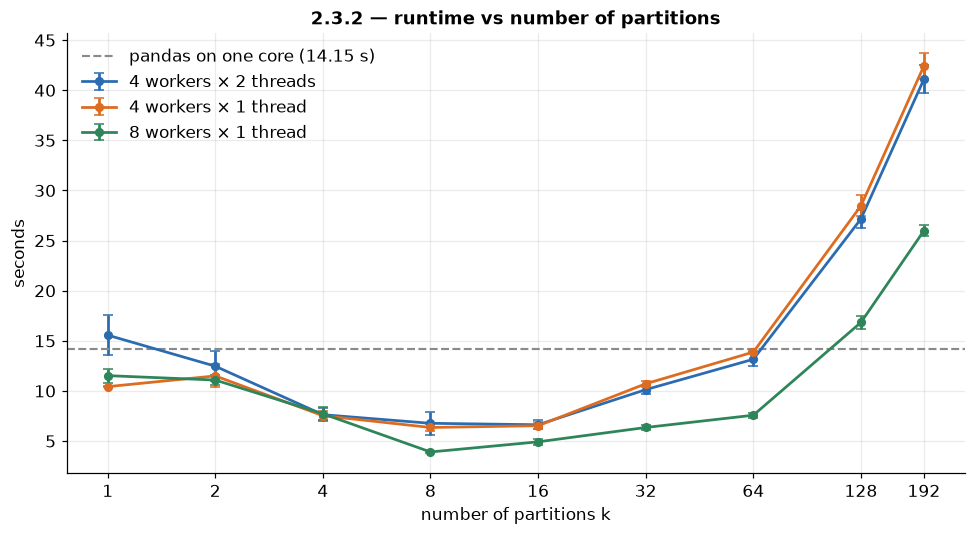

In [2]:
fig, ax = plt.subplots(figsize=(9, 5))

for config, color, name in [("4x2", BLUE, label(4, 2)),
                            ("4x1", ORANGE, label(4, 1)),
                            ("8x1", GREEN, label(8, 1))]:
    curve = distributed[distributed.config == config].groupby("partizioni").secondi.agg(["mean", "std"])
    ax.errorbar(curve.index, curve["mean"], yerr=curve["std"], marker="o", ms=5,
                lw=1.8, capsize=3, color=color, label=name)

ax.axhline(pandas_seconds, ls="--", lw=1.4, color=GREY,
           label=f"pandas on one core ({pandas_seconds:.2f} s)")
ax.set_xscale("log", base=2)
ax.set_xticks(k_values)
ax.set_xticklabels(k_values)
ax.set_xlabel("number of partitions k")
ax.set_ylabel("seconds")
ax.set_title("2.3.2 — runtime vs number of partitions")
ax.legend()
fig.tight_layout()

## Runtime vs number of workers

Measured at `k=16`, with 2 threads per worker. On the right, the speedup over a single worker against the ideal line.

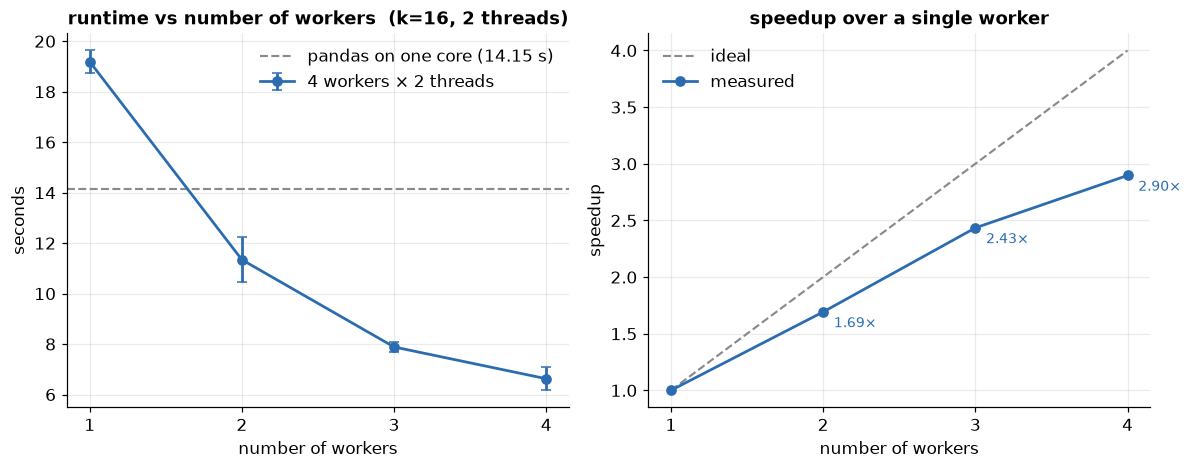

In [3]:
curve = (distributed[(distributed.thread == 2 * distributed.worker) & (distributed.partizioni == 16)]
         .groupby("worker").secondi.agg(["mean", "std"]))
speedup = curve["mean"].iloc[0] / curve["mean"]

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4.4))

left.errorbar(curve.index, curve["mean"], yerr=curve["std"], marker="o", ms=6,
              lw=1.8, capsize=3, color=BLUE, label=label(4, 2))
left.axhline(pandas_seconds, ls="--", lw=1.4, color=GREY,
             label=f"pandas on one core ({pandas_seconds:.2f} s)")
left.set_xticks(curve.index)
left.set_xlabel("number of workers")
left.set_ylabel("seconds")
left.set_title("runtime vs number of workers  (k=16, 2 threads)")
left.legend()

right.plot(curve.index, curve.index, ls="--", lw=1.4, color=GREY, label="ideal")
right.plot(curve.index, speedup, marker="o", ms=6, lw=1.8, color=BLUE, label="measured")
for workers, value in speedup.items():
    if workers > 1:
        right.annotate(f"{value:.2f}×", (workers, value), textcoords="offset points",
                       xytext=(7, -10), fontsize=9, color=BLUE)
right.set_xticks(curve.index)
right.set_xlabel("number of workers")
right.set_ylabel("speedup")
right.set_title("speedup over a single worker")
right.legend()
fig.tight_layout()

## Processes vs threads, at equal core count

The six configurations measured at `k=16`. In brackets, the cluster cores each one occupies.

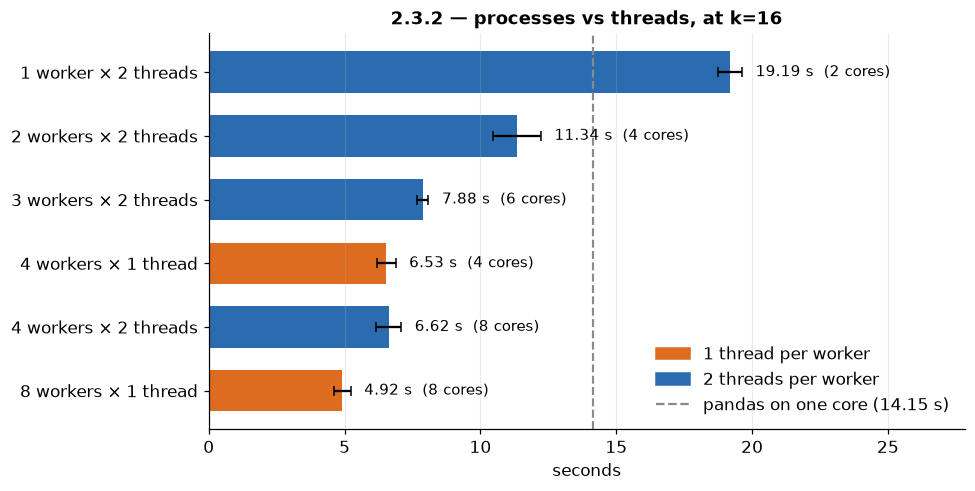

In [4]:
order = ["1x2", "2x2", "3x2", "4x1", "4x2", "8x1"]
at_k16 = distributed[distributed.partizioni == 16].groupby("config").secondi.agg(["mean", "std"]).loc[order]
names = [label(int(c.split("x")[0]), int(c.split("x")[1])) for c in order]
cores = [int(c.split("x")[0]) * int(c.split("x")[1]) for c in order]
colors = [ORANGE if c.endswith("x1") else BLUE for c in order]

fig, ax = plt.subplots(figsize=(9, 4.6))
bars = ax.barh(names, at_k16["mean"], xerr=at_k16["std"], color=colors, height=0.65, capsize=3)
for bar, seconds, sd, n in zip(bars, at_k16["mean"], at_k16["std"], cores):
    ax.text(seconds + sd + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{seconds:.2f} s  ({n} cores)", va="center", fontsize=10)

ax.axvline(pandas_seconds, ls="--", lw=1.4, color=GREY)
ax.legend(handles=[Patch(color=ORANGE, label="1 thread per worker"),
                   Patch(color=BLUE, label="2 threads per worker"),
                   Line2D([], [], ls="--", color=GREY,
                          label=f"pandas on one core ({pandas_seconds:.2f} s)")],
          loc="lower right")
ax.invert_yaxis()
ax.set_xlim(0, at_k16["mean"].max() * 1.45)
ax.set_xlabel("seconds")
ax.set_title("2.3.2 — processes vs threads, at k=16")
ax.grid(axis="y", visible=False)
fig.tight_layout()